# Структура работы

Данную работу можно разделить на 5 фрагментов

*   Загрузка и обработка данных из PDF
*   Различные RAG системы созданные с помощью разных инструментов а также разной сложности решений
*   Описание метрик и написание функций их расчета
*   Сравнение всех систем по этим метрикам
*   Deploy модели. Более подробно о нём будет сказано на github

# Установка и загрузка всего необходимого

In [ ]:
# Единая установка всех библиотек с совместимыми версиями
!pip install -q \
    pdfplumber \
    faiss-cpu \
    pypdf \
    langchain \
    langchain-community \
    "langchain-huggingface<1.3.0" \
    langchain-qdrant \
    qdrant-client \
    sentence-transformers \
    "transformers<5.0.0" \
    accelerate \
    torch \
    ragas \
    rapidfuzz \
    openai \
    tqdm \
    python-dotenv


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Kirill\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
!wget -O docs.zip https://files.infotecs.ru/_dl/sess/vipnet_coordinator_hw5/docs/ViPNet%20Coordinator%20HW%205.3.2_docs.zip
!unzip docs.zip -d data/

--2026-02-16 15:20:16--  https://files.infotecs.ru/_dl/sess/vipnet_coordinator_hw5/docs/ViPNet%20Coordinator%20HW%205.3.2_docs.zip
Resolving files.infotecs.ru (files.infotecs.ru)... 185.169.155.77
Connecting to files.infotecs.ru (files.infotecs.ru)|185.169.155.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21555240 (21M) [application/zip]
Saving to: ‘docs.zip’

docs.zip            100%[===================>]  20.56M  5.94MB/s    in 3.8s    

2026-02-16 15:20:21 (5.43 MB/s) - ‘docs.zip’ saved [21555240/21555240]

Archive:  docs.zip
  inflating: data/01 ViPNet Coordinator HW 5. Подготовка к работе.pdf  
  inflating: data/02 ViPNet Coordinator HW 5. Настройка в CLI.pdf  
  inflating: data/03 ViPNet Coordinator HW 5. Настройка в WEB.pdf  
  inflating: data/04 ViPNet Coordinator HW 5. Справочник.pdf  
  inflating: data/06 ViPNet Coordinator HW 5. История версий.pdf  
  inflating: data/07 ViPNet Coordinator HW 5. Перечень совместимых трансиверов.pdf  


#### Импортируем, чтобы проверить установку

In [3]:
# Стандартные библиотеки
import os
import re
import json
import time
import threading
import subprocess
from typing import List, Dict, Any, Optional

# Основные библиотеки для работы с данными
import numpy as np
import pandas as pd
from tqdm import tqdm

# PDF обработка
import pdfplumber
from pypdf import PdfReader

# Визуализация (опционально)
import matplotlib.pyplot as plt
import seaborn as sns

# FAISS для векторного поиска
import faiss

# Sentence Transformers для эмбеддингов
from sentence_transformers import SentenceTransformer

# Трансформеры и модели от Hugging Face
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline,
    AutoModel
)

# PyTorch
import torch

# LangChain компоненты
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import RetrievalQA
from langchain_classic.schema.output_parser import StrOutputParser

# Qdrant векторная БД
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore

# RAGAS для оценки
from ragas import EvaluationDataset, evaluate
from ragas.llms import llm_factory
from ragas.embeddings import HuggingFaceEmbeddings as RagasHFEmbeddings
from ragas.testset import TestsetGenerator
from ragas.metrics import (
    context_precision,
    context_recall,
    faithfulness,
    answer_correctness
)
from ragas.metrics.collections import (
    ContextPrecision,
    ContextRecall,
    Faithfulness,
    AnswerCorrectness
)

# OpenAI / OpenRouter клиент
from openai import OpenAI

# Управление переменными окружения
from dotenv import load_dotenv

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipython-input-344099632.py:59: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipython-input-344099632.py:59: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics im

# Загрузка и обработка данных из PDF

## Извлечение текста из PDF

In [ ]:
def text_from_pdf(data_path):
  docs = []
  for file in os.listdir(data_path):
    with pdfplumber.open(os.path.join(data_path, file)) as pdf:
      all_text = ""
      for page in pdf.pages:
        all_text += page.extract_text() + "\n"
      docs.append({
          'file_name': file,
          'text': all_text,
      })
  return docs

### Функция очистки текста

Спасибо LLM за избавление разработчика от прописывания различных re шаблонов для очистки и ручного анализа текста

In [ ]:
import re
from typing import List, Dict, Any, Optional

def clean_text_for_rag(input_data: List[Dict[str, Any]], text_name = 'text') -> List[Dict[str, Any]]:
    """
    Очищает текст из документов для использования в RAG системе

    Args:
        input_data: Список словарей с ключами 'file_name' и 'text'

    Returns:
        Очищенный список словарей
    """
    cleaned_data = []

    for item in input_data:
        text = item[text_name]

        # Удаляем оглавление и его остатки
        text = remove_table_of_contents(text)
        text = remove_toc_leftovers(text)

        # Удаляем колонтитулы и номера страниц
        text = re.sub(r'\n\s*\d+\s*\n', '\n', text)
        text = re.sub(r'© АО «ИнфоТеКС», \d{4}', '', text)
        text = re.sub(r'ФРКЕ\.\d+\.\d+ИС\d', '', text)
        text = re.sub(r'Версия продукта [\d\.]+, документ обновлен [\d\.]+', '', text)

        # Удаляем номера страниц в формате "| 13", "| 14"
        text = re.sub(r'\|\s*\d+\s*$', '', text, flags=re.MULTILINE)
        text = re.sub(r'^\s*\|\s*\d+\s*$', '', text, flags=re.MULTILINE)

        # Удаляем информацию о товарных знаках и копирайте
        copyright_patterns = [
            r'Ни одна из частей этого документа.*?письменного разрешения АО «ИнфоТеКС»\.',
            r'ViPNet является зарегистрированным товарным знаком АО «ИнфоТеКС»\.',
            r'Все названия компаний.*?принадлежат соответствующим владельцам\.',
            r'Copyright \(c\) InfoTeCS',
            r'®',
            r'™'
        ]

        for pattern in copyright_patterns:
            text = re.sub(pattern, '', text, flags=re.DOTALL)

        # Удаляем контактную информацию
        contact_patterns = [
            r'АО «ИнфоТеКС»[\s\S]*?тел\.?[:\s]*[+]?[\d\s()-]{10,}',
            r'Телефон:.*?(?=\n|$)',
            r'Сайт:.*?(?=\n|$)',
            r'Служба поддержки:.*?(?=\n|$)',
            r'125167, г\. Москва,.*?(?=\n|$)',
            r'8 \(800\) 250-0260.*?(?=\n|$)',
            r'\+7 \(495\) 737-6192.*?(?=\n|$)',
            r'infotecs\.ru',
            r'hotline@infotecs\.ru'
        ]

        for pattern in contact_patterns:
            text = re.sub(pattern, '', text, flags=re.IGNORECASE)

        # Удаляем строки с моделями устройств
        lines = text.split('\n')
        filtered_lines = []

        for line in lines:
            line = line.strip()

            if not line:
                continue

            if re.match(r'^ViPNet Coordinator.*(HW\d+|VA)$', line):
                continue

            if re.match(r'^Версия продукта:?.*$', line, re.IGNORECASE):
                continue

            filtered_lines.append(line)

        text = ' '.join(filtered_lines)

        # Удаляем маркеры списков и специальные символы
        text = re.sub(r'[•·]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'\n\s*\n', '\n', text)

        # Финальная очистка
        text = text.strip()
        text = re.sub(r'^[.\s]+|[.\s]+$', '', text)

        cleaned_item = {
            'file_name': item['file_name'],
            'text': text
        }
        cleaned_data.append(cleaned_item)

    return cleaned_data


def remove_toc_leftovers(text: str) -> str:
    """
    Удаляет остатки оглавления, которые не были удалены на первом этапе
    """
    lines = text.split('\n')
    filtered_lines = []

    # Паттерны для строк оглавления, которые могут быть в середине документа
    toc_mid_patterns = [
        r'(?i)^\s*(приложение\s+[a-zа-я]\.?\s*.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(неполадки в работе.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(ошибка создания.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(низкая скорость.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(особенности.*?)(?:\d+\s*$)?',
        r'(?i)^\s*после настройки.*?(?:\d+\s*$)?',
        r'(?i)^\s*не отображаются.*?(?:\d+\s*$)?',
        r'(?i)^\s*блокирование.*?(?:\d+\s*$)?',
    ]

    # Паттерны для заголовков с номерами страниц сразу после текста
    header_with_page_patterns = [
        r'(?i)^\s*(о документе|соглашения документа|обратная связь|введение)\s+\d+\s*$',
        r'^\s*[А-Я][а-я]+\s+\d+\s*$',  # Любое слово с большой буквы + число
    ]

    skip_next = False

    for i, line in enumerate(lines):
        if skip_next:
            skip_next = False
            continue

        original_line = line
        line = line.strip()

        # Пропускаем пустые строки
        if not line:
            continue

        # Проверяем на заголовки с номерами страниц
        is_header_with_page = False
        for pattern in header_with_page_patterns:
            if re.search(pattern, line, re.IGNORECASE):
                is_header_with_page = True
                break

        if is_header_with_page:
            # Пропускаем следующую строку, если она пустая или содержит номер
            if i + 1 < len(lines) and re.match(r'^\s*\|\s*\d+\s*$', lines[i + 1]):
                skip_next = True
            continue

        # Проверяем на строки оглавления в середине документа
        is_toc_mid = False
        for pattern in toc_mid_patterns:
            if re.search(pattern, line, re.IGNORECASE):
                # Проверяем, не является ли это реальным заголовком раздела
                if not line.endswith('.') and len(line) < 80:
                    is_toc_mid = True
                    break

        if is_toc_mid:
            continue

        # Удаляем строки с точками-заполнителями и номерами страниц
        if re.search(r'[\.\-\s]{10,}.*?\d+\s*$', line):
            continue

        # Удаляем строки с номерами страниц в конце
        if re.match(r'^.*?\d+\s*$', line) and len(line) < 100:
            if not re.search(r'[а-яА-Яa-zA-Z]{4,}.*\d', line):
                digits = sum(c.isdigit() for c in line)
                letters = sum(c.isalpha() for c in line)
                if digits > letters * 0.3:
                    continue

        # Удаляем строки вида "Глава X. Название ......... NNN"
        if re.search(r'(?i)^\s*глав[аы]\s*\d+.*?[\.\-\s]{5,}.*?\d+\s*$', line):
            continue

        # Удаляем строки с номерами разделов и точками
        if re.search(r'^\s*\d+\.?\d*\s+[а-яА-Яa-zA-Z].*?[\.\-\s]{5,}', line):
            continue

        # Удаляем строки, где есть только номер страницы или точки
        if re.match(r'^\s*[\d\.\-\s]+$', line):
            continue

        # Удаляем строки, где большая часть - это точки/тире
        dots_and_dashes = len(re.findall(r'[\.\-]', line))
        if dots_and_dashes > len(line) * 0.3:
            continue

        # Удаляем строки, которые выглядят как заголовки оглавления
        if re.search(r'(?i)(содержание|оглавление|contents?|table\s+of\s+contents)', line):
            continue

        # Удаляем строки с диапазонами страниц
        if re.search(r'\d+\s*[-–—]\s*\d+\s*$', line) and len(line) < 80:
            continue

        # Удаляем строки вида "ViPNet Coordinator HW 5. Настройка ... | 13"
        if re.search(r'^.*\|\s*\d+\s*$', line):
            continue

        filtered_lines.append(original_line.rstrip())

    return '\n'.join(filtered_lines)


def remove_table_of_contents(text: str) -> str:
    """
    Удаляет оглавление (Table of Contents) из текста документа
    """
    # Паттерн для поиска начала оглавления
    toc_start_patterns = [
        r'(?i)^\s*содержан(ие|ия)\s*[\n\r]',
        r'(?i)^\s*оглавлен(ие|ия)\s*[\n\r]',
        r'(?i)^\s*table\s+of\s+contents\s*[\n\r]',
        r'(?i)^\s*contents?\s*[\n\r]',
    ]

    lines = text.split('\n')
    toc_end_index = -1
    toc_start_index = -1

    # Ищем начало оглавления
    for i, line in enumerate(lines[:150]):
        for pattern in toc_start_patterns:
            if re.match(pattern, line, re.IGNORECASE):
                toc_start_index = i
                break
        if toc_start_index != -1:
            break

    # Если нашли начало, ищем конец
    if toc_start_index != -1:
        consecutive_non_toc = 0
        for i in range(toc_start_index + 1, len(lines)):
            line = lines[i].strip()
            if not line:
                continue

            if is_toc_line(line):
                consecutive_non_toc = 0
                toc_end_index = i
            else:
                consecutive_non_toc += 1
                if consecutive_non_toc >= 5:  # Увеличили с 3 до 5 для надежности
                    break

        if toc_end_index != -1:
            before_toc = lines[:toc_start_index]
            after_toc = lines[toc_end_index + 1:]

            # Удаляем заголовок "Содержание"
            if before_toc and re.match(r'(?i)^\s*содержан|оглавлен', before_toc[-1]):
                before_toc = before_toc[:-1]

            return '\n'.join(before_toc + after_toc)

    return text


def is_toc_line(line: str) -> bool:
    """Проверяет, является ли строка частью оглавления"""
    line = line.strip()
    if not line:
        return False

    # Паттерн: точки/тире + номер страницы
    if re.search(r'[\.\-\s]{8,}.*?\d+', line):
        return True

    # Паттерн: номер главы + название + номер страницы
    if re.search(r'^\s*(\d+\.?\d*|[IVXLCDM]+\.?)\s+\D+\d+\s*$', line):
        return True

    # Паттерн: строка заканчивается номером страницы и содержит маркер главы
    if re.search(r'(?i)(глав[аы]|раздел|часть|section|chapter).*\d+\s*$', line):
        return True

    # Строки с "Приложение X." и номером страницы
    if re.search(r'(?i)^\s*приложение\s+[a-zа-я]\.?\s+.*?\d+\s*$', line):
        return True

    # Строки с типичными проблемами из оглавления
    if re.search(r'(?i)(неполадки|ошибка|низкая скорость|особенности|не отображаются|блокирование).*\d+\s*$', line):
        return True

    return False


def clean_technical_documentation(text: str) -> str:
    """
    Специализированная очистка для технической документации
    """
    # Удаляем остатки оглавления
    text = remove_toc_leftovers(text)

    # Удаляем строки, которые начинаются с "Глава" и содержат многоточия
    text = re.sub(r'(?im)^\s*глав[аы]\s+\d+.*?[\.\-\s]{10,}.*?\d+\s*$\n?', '', text)

    # Удаляем строки с номерами страниц в формате "...... 137"
    text = re.sub(r'(?im)^.*?[\.\-\s]{15,}\s*\d+\s*$\n?', '', text)

    # Удаляем изолированные номера страниц
    text = re.sub(r'(?im)^\s*\d+\s*$\n?', '', text)

    # Удаляем строки с диапазонами страниц
    text = re.sub(r'(?im)^.*?\d+\s*[-–—]\s*\d+\s*$\n?', '', text)

    # Удаляем строки-заголовки с номерами страниц
    text = re.sub(r'(?im)^\s*[А-Я][а-я]+\s+\d+\s*$\n?', '', text)
    text = re.sub(r'(?im)^\s*о документе\s+\d+\s*$\n?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'(?im)^\s*соглашения документа\s+\d+\s*$\n?', '', text, flags=re.IGNORECASE)

    # Удаляем маркеры списков
    text = re.sub(r'[•·]', ' ', text)

    # Нормализуем переносы строк
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text

### Очистка текста

In [ ]:
docs_dirty = text_from_pdf('data')

In [ ]:
docs = clean_text_for_rag(docs_dirty)

In [ ]:
for i in range(len(docs)):
  print(f"Из документа {docs[i]['file_name']} было удалено {len(docs_dirty[i]['text'])-len(docs[i]['text'])} символов")

Из документа 02 ViPNet Coordinator HW 5. Настройка в CLI.pdf было удалено 92132 символов
Из документа 07 ViPNet Coordinator HW 5. Перечень совместимых трансиверов.pdf было удалено 1113 символов
Из документа 01 ViPNet Coordinator HW 5. Подготовка к работе.pdf было удалено 17687 символов
Из документа 03 ViPNet Coordinator HW 5. Настройка в WEB.pdf было удалено 55509 символов
Из документа 06 ViPNet Coordinator HW 5. История версий.pdf было удалено 424 символов
Из документа 04 ViPNet Coordinator HW 5. Справочник.pdf было удалено 158838 символов


# Baseline

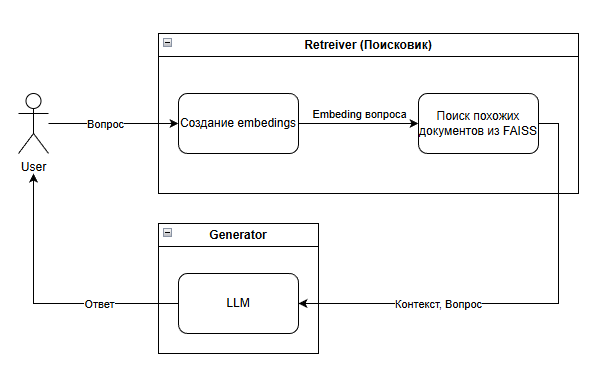

Baseline: классический RAG-подход с моделями из Hugging Face, индексом FAISS и простым символьным разбиением текста на чанки с перекрытием.

## Загрузка моделей

В качестве baseline используются компактные модели с малым числом параметров для высокой скорости и простоты:

*   Генеративная модель: Qwen3-0.6B
*   Эмбеддинг-модель: Qwen3-Embedding-0.6B

Модели показывают достойное качество при минимальных вычислительных затратах.

In [ ]:
embedding_model = SentenceTransformer('Qwen/Qwen3-Embedding-0.6B')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
model_name = "Qwen/Qwen3-0.6B"

# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype="auto"  # Автоматически выбирает подходящий dtype (float16/bfloat16/float32)
)

# Настройка паддинг-токена (если не установлен)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Создание пайплайна для генерации текста
qa_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    do_sample=False,
    max_new_tokens=512,
    max_length = None,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    return_full_text=False
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_length', 'pad_token_id', 'eos_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


## Разбиение текста на чанки и создание эмбеддингов

### Разбиение текста на чанки

In [ ]:
def split_text_into_chunks(text: str, chunk_size: int = 500, overlap: int = 100) -> List[str]:
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

### Создание Embeddings

In [ ]:
def create_embeddings(docs):
    embeddings = []
    texts = [doc['text'] for doc in docs]
    vectors = embedding_model.encode(texts)
    for i, doc in enumerate(docs):
        if 'text' in doc and doc['text'].strip():
            embeddings.append({
                "text": doc['text'],
                "vector": vectors[i]
            })
    return embeddings

In [ ]:
def embedding_pipeline(docs, chunk_size, overlap):
  texts_chunked = [
    {'file_name': doc['file_name'],
     'text': chunk}
    for doc in docs
    for chunk in split_text_into_chunks(doc['text'], chunk_size, overlap)
    if chunk.strip()
  ]
  embeddings = create_embeddings(texts_chunked)
  return embeddings


## Создание индекса FAISS

In [ ]:
def create_vectors(embeddings):
  # Преобразование векторов в NumPy
  vectors = [emb['vector'] for emb in embeddings]
  vectors = np.array(vectors).astype('float32')
  texts = [emb['text'] for emb in embeddings]

  # Создание индекса FAISS
  index = faiss.IndexFlatL2(vectors.shape[1])  # L2 норма
  index.add(vectors)

  return index, texts


In [ ]:
embeddings = embedding_pipeline(docs, 1000, 200)
index, texts = create_vectors(embeddings)

### Сохрание индекса и текстов для дальнейшего использования(в том числе деплоя)

In [ ]:
faiss.write_index(index, 'data.index')

In [ ]:
with open("texts.txt", "w") as file:
    file.write("\n".join(texts))

### Загрузка индекса и текстов

In [ ]:
index = faiss.read_index('data.index')

In [ ]:
with open("texts.txt", "r", encoding="utf-8") as file:
    texts = file.read().split('\n')

## Поиск чанков по индексу FAISS

In [ ]:
def search_relevant_chunks(query, index, texts, top_k=3):
    query_vector = embedding_model.encode([query])[0].astype('float32')
    query_vector = np.expand_dims(query_vector, axis=0)

    distances, indices = index.search(query_vector, top_k)
    relevant_chunks = [texts[i] for i in indices[0]]
    return relevant_chunks, distances


## Генерация ответа LLM и его обработка

In [ ]:
def generate_answer(query, relevant_chunks, max_context_size):
    if not relevant_chunks:
        return "Не удалось найти релевантные фрагменты.", 0.0

    context = " ".join(relevant_chunks)[:max_context_size]
    if not context.strip():
        return "Контекст пуст. Невозможно сгенерировать ответ.", 0.0

    system_prompt = """Ты консультант по продукции InfoTecs. Тебе необходимо ответить на вопрос пользователя, используя данный тебе контекст. Ответ должен быть объёмным и закрыть все вопросы пользователя.

ВАЖНЫЕ ПРАВИЛА ФОРМАТИРОВАНИЯ:
1. Начинай свой ответ строго с "ANSWER:"
2. Заканчивай свой ответ строго с "[END ANSWER]"
3. Ничего не пиши до ANSWER: и после [END ANSWER]

Пример правильного ответа:
ANSWER: Ваш развернутый ответ на вопрос пользователя здесь... [END ANSWER]"""

    input_text = f"{system_prompt}\n\nВопрос: {query}\nКонтекст: {context}\n:"

    # Генерация ответа
    generated_output = qa_pipeline(input_text)[0]['generated_text']

    return generated_output

In [ ]:
def postprocess_answer(generated_output: str) -> str:
    """
    Извлекает чистый ответ модели из сгенерированного текста, удаляя системный промпт
    и служебные маркеры. Поддерживает вариации форматирования.

    Args:
        generated_output: Полный вывод пайплайна (промпт + ответ модели).

    Returns:
        Очищенный ответ модели или пустая строка, если извлечь не удалось.
    """
    if not generated_output or not isinstance(generated_output, str):
        return ""

    # 1. Пытаемся найти текст строго между ANSWER: и [END ANSWER]
    pattern = r'ANSWER:\s*(.*?)\s*\[END ANSWER\]'
    match = re.search(pattern, generated_output, re.DOTALL | re.IGNORECASE)
    if match:
        answer = match.group(1).strip()
        if answer:
            return answer

    # 2. Если первый способ не сработал, ищем последнее вхождение ANSWER:
    #    и затем пытаемся обрезать до [END ANSWER] (если есть)
    parts = re.split(r'ANSWER:\s*', generated_output, flags=re.IGNORECASE)
    if len(parts) > 1:
        # Берём текст после последнего ANSWER:
        after_last = parts[-1].strip()
        # Ищем закрывающий маркер
        end_marker = '[END ANSWER]'
        end_pos = after_last.lower().find(end_marker.lower())
        if end_pos != -1:
            answer = after_last[:end_pos].strip()
        else:
            answer = after_last
        if answer:
            return answer

    # 3. Если ни один из способов не дал результата,
    #    возвращаем исходную строку (на всякий случай обрезанную)
    return generated_output.strip()

## System pipeline

In [ ]:
def system_pipline(query, index=index, texts=texts, top_k=5, max_context_size=1000):
  # Ввод пользователя
  user_input = query
  if user_input.lower() == 'exit':
      return

  relevant_chunks, distances = search_relevant_chunks(user_input, index, texts, top_k)

  generated_output = generate_answer(user_input, relevant_chunks, max_context_size)
  answer = postprocess_answer(generated_output)
  return answer, relevant_chunks

# Langchain

**Реализация на LangChain:**
Система построена на фреймворке LangChain, который предоставляет готовые компоненты для создания RAG-пайплайнов (от загрузки PDF до работы с векторными БД).

**Ключевые улучшения baseline:**
- Структурированное хранение документов и промптов (через классы)
- Интеграция с QDRANT как векторной БД
- Более умное разбиение текста через RecursiveCharacterTextSplitter (сохраняет целостность слов)
- Готовая интеграция с RAGAS для последующей оценки качества

## Загрузка документов и разбиение на чанки

In [ ]:
# 1. Загрузка документов из папки
loader = DirectoryLoader(
    path="data",  # Папка с вашими PDF файлами
    glob="**/*.pdf",
    loader_cls=PyPDFLoader
)
documents = loader.load()
print(f"Загружено документов: {len(documents)}")

Загружено документов: 1483


In [ ]:
len(documents)

1483

### Очистка документов

In [ ]:
# @title
import re
from typing import List, Dict, Any, Optional

def clean_text_for_rag(input_text: str) -> str:
    """
    Очищает текст для использования в RAG системе

    Args:
        input_text: Входная строка с текстом документа

    Returns:
        Очищенная строка
    """
    text = input_text

    # Удаляем оглавление и его остатки
    text = remove_table_of_contents(text)
    text = remove_toc_leftovers(text)

    # Удаляем колонтитулы и номера страниц
    text = re.sub(r'\n\s*\d+\s*\n', '\n', text)
    text = re.sub(r'© АО «ИнфоТеКС», \d{4}', '', text)
    text = re.sub(r'ФРКЕ\.\d+\.\d+ИС\d', '', text)
    text = re.sub(r'Версия продукта [\d\.]+, документ обновлен [\d\.]+', '', text)

    # Удаляем номера страниц в формате "| 13", "| 14"
    text = re.sub(r'\|\s*\d+\s*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\s*\|\s*\d+\s*$', '', text, flags=re.MULTILINE)

    # Удаляем информацию о товарных знаках и копирайте
    copyright_patterns = [
        r'Ни одна из частей этого документа.*?письменного разрешения АО «ИнфоТеКС»\.',
        r'ViPNet является зарегистрированным товарным знаком АО «ИнфоТеКС»\.',
        r'Все названия компаний.*?принадлежат соответствующим владельцам\.',
        r'Copyright \(c\) InfoTeCS',
        r'®',
        r'™'
    ]

    for pattern in copyright_patterns:
        text = re.sub(pattern, '', text, flags=re.DOTALL)

    # Удаляем контактную информацию
    contact_patterns = [
        r'АО «ИнфоТеКС»[\s\S]*?тел\.?[:\s]*[+]?[\d\s()-]{10,}',
        r'Телефон:.*?(?=\n|$)',
        r'Сайт:.*?(?=\n|$)',
        r'Служба поддержки:.*?(?=\n|$)',
        r'125167, г\. Москва,.*?(?=\n|$)',
        r'8 \(800\) 250-0260.*?(?=\n|$)',
        r'\+7 \(495\) 737-6192.*?(?=\n|$)',
        r'infotecs\.ru',
        r'hotline@infotecs\.ru'
    ]

    for pattern in contact_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # Удаляем строки с моделями устройств
    lines = text.split('\n')
    filtered_lines = []

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if re.match(r'^ViPNet Coordinator.*(HW\d+|VA)$', line):
            continue

        if re.match(r'^Версия продукта:?.*$', line, re.IGNORECASE):
            continue

        filtered_lines.append(line)

    text = ' '.join(filtered_lines)

    # Удаляем маркеры списков и специальные символы
    text = re.sub(r'[•·]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n\s*\n', '\n', text)

    # Финальная очистка
    text = text.strip()
    text = re.sub(r'^[.\s]+|[.\s]+$', '', text)

    return text


def remove_toc_leftovers(text: str) -> str:
    """
    Удаляет остатки оглавления, которые не были удалены на первом этапе
    """
    lines = text.split('\n')
    filtered_lines = []

    # Паттерны для строк оглавления, которые могут быть в середине документа
    toc_mid_patterns = [
        r'(?i)^\s*(приложение\s+[a-zа-я]\.?\s*.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(неполадки в работе.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(ошибка создания.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(низкая скорость.*?)(?:\d+\s*$)?',
        r'(?i)^\s*(особенности.*?)(?:\d+\s*$)?',
        r'(?i)^\s*после настройки.*?(?:\d+\s*$)?',
        r'(?i)^\s*не отображаются.*?(?:\d+\s*$)?',
        r'(?i)^\s*блокирование.*?(?:\d+\s*$)?',
    ]

    # Паттерны для заголовков с номерами страниц сразу после текста
    header_with_page_patterns = [
        r'(?i)^\s*(о документе|соглашения документа|обратная связь|введение)\s+\d+\s*$',
        r'^\s*[А-Я][а-я]+\s+\d+\s*$',  # Любое слово с большой буквы + число
    ]

    skip_next = False

    for i, line in enumerate(lines):
        if skip_next:
            skip_next = False
            continue

        original_line = line
        line = line.strip()

        # Пропускаем пустые строки
        if not line:
            continue

        # Проверяем на заголовки с номерами страниц
        is_header_with_page = False
        for pattern in header_with_page_patterns:
            if re.search(pattern, line, re.IGNORECASE):
                is_header_with_page = True
                break

        if is_header_with_page:
            # Пропускаем следующую строку, если она пустая или содержит номер
            if i + 1 < len(lines) and re.match(r'^\s*\|\s*\d+\s*$', lines[i + 1]):
                skip_next = True
            continue

        # Проверяем на строки оглавления в середине документа
        is_toc_mid = False
        for pattern in toc_mid_patterns:
            if re.search(pattern, line, re.IGNORECASE):
                # Проверяем, не является ли это реальным заголовком раздела
                if not line.endswith('.') and len(line) < 80:
                    is_toc_mid = True
                    break

        if is_toc_mid:
            continue

        # Удаляем строки с точками-заполнителями и номерами страниц
        if re.search(r'[\.\-\s]{10,}.*?\d+\s*$', line):
            continue

        # Удаляем строки с номерами страниц в конце
        if re.match(r'^.*?\d+\s*$', line) and len(line) < 100:
            if not re.search(r'[а-яА-Яa-zA-Z]{4,}.*\d', line):
                digits = sum(c.isdigit() for c in line)
                letters = sum(c.isalpha() for c in line)
                if digits > letters * 0.3:
                    continue

        # Удаляем строки вида "Глава X. Название ......... NNN"
        if re.search(r'(?i)^\s*глав[аы]\s*\d+.*?[\.\-\s]{5,}.*?\d+\s*$', line):
            continue

        # Удаляем строки с номерами разделов и точками
        if re.search(r'^\s*\d+\.?\d*\s+[а-яА-Яa-zA-Z].*?[\.\-\s]{5,}', line):
            continue

        # Удаляем строки, где есть только номер страницы или точки
        if re.match(r'^\s*[\d\.\-\s]+$', line):
            continue

        # Удаляем строки, где большая часть - это точки/тире
        dots_and_dashes = len(re.findall(r'[\.\-]', line))
        if dots_and_dashes > len(line) * 0.3:
            continue

        # Удаляем строки, которые выглядят как заголовки оглавления
        if re.search(r'(?i)(содержание|оглавление|contents?|table\s+of\s+contents)', line):
            continue

        # Удаляем строки с диапазонами страниц
        if re.search(r'\d+\s*[-–—]\s*\d+\s*$', line) and len(line) < 80:
            continue

        # Удаляем строки вида "ViPNet Coordinator HW 5. Настройка ... | 13"
        if re.search(r'^.*\|\s*\d+\s*$', line):
            continue

        filtered_lines.append(original_line.rstrip())

    return '\n'.join(filtered_lines)


def remove_table_of_contents(text: str) -> str:
    """
    Удаляет оглавление (Table of Contents) из текста документа
    """
    # Паттерн для поиска начала оглавления
    toc_start_patterns = [
        r'(?i)^\s*содержан(ие|ия)\s*[\n\r]',
        r'(?i)^\s*оглавлен(ие|ия)\s*[\n\r]',
        r'(?i)^\s*table\s+of\s+contents\s*[\n\r]',
        r'(?i)^\s*contents?\s*[\n\r]',
    ]

    lines = text.split('\n')
    toc_end_index = -1
    toc_start_index = -1

    # Ищем начало оглавления
    for i, line in enumerate(lines[:150]):
        for pattern in toc_start_patterns:
            if re.match(pattern, line, re.IGNORECASE):
                toc_start_index = i
                break
        if toc_start_index != -1:
            break

    # Если нашли начало, ищем конец
    if toc_start_index != -1:
        consecutive_non_toc = 0
        for i in range(toc_start_index + 1, len(lines)):
            line = lines[i].strip()
            if not line:
                continue

            if is_toc_line(line):
                consecutive_non_toc = 0
                toc_end_index = i
            else:
                consecutive_non_toc += 1
                if consecutive_non_toc >= 5:  # Увеличили с 3 до 5 для надежности
                    break

        if toc_end_index != -1:
            before_toc = lines[:toc_start_index]
            after_toc = lines[toc_end_index + 1:]

            # Удаляем заголовок "Содержание"
            if before_toc and re.match(r'(?i)^\s*содержан|оглавлен', before_toc[-1]):
                before_toc = before_toc[:-1]

            return '\n'.join(before_toc + after_toc)

    return text


def is_toc_line(line: str) -> bool:
    """Проверяет, является ли строка частью оглавления"""
    line = line.strip()
    if not line:
        return False

    # Паттерн: точки/тире + номер страницы
    if re.search(r'[\.\-\s]{8,}.*?\d+', line):
        return True

    # Паттерн: номер главы + название + номер страницы
    if re.search(r'^\s*(\d+\.?\d*|[IVXLCDM]+\.?)\s+\D+\d+\s*$', line):
        return True

    # Паттерн: строка заканчивается номером страницы и содержит маркер главы
    if re.search(r'(?i)(глав[аы]|раздел|часть|section|chapter).*\d+\s*$', line):
        return True

    # Строки с "Приложение X." и номером страницы
    if re.search(r'(?i)^\s*приложение\s+[a-zа-я]\.?\s+.*?\d+\s*$', line):
        return True

    # Строки с типичными проблемами из оглавления
    if re.search(r'(?i)(неполадки|ошибка|низкая скорость|особенности|не отображаются|блокирование).*\d+\s*$', line):
        return True

    return False


def clean_technical_documentation(text: str) -> str:
    """
    Специализированная очистка для технической документации
    """
    # Удаляем остатки оглавления
    text = remove_toc_leftovers(text)

    # Удаляем строки, которые начинаются с "Глава" и содержат многоточия
    text = re.sub(r'(?im)^\s*глав[аы]\s+\d+.*?[\.\-\s]{10,}.*?\d+\s*$\n?', '', text)

    # Удаляем строки с номерами страниц в формате "...... 137"
    text = re.sub(r'(?im)^.*?[\.\-\s]{15,}\s*\d+\s*$\n?', '', text)

    # Удаляем изолированные номера страниц
    text = re.sub(r'(?im)^\s*\d+\s*$\n?', '', text)

    # Удаляем строки с диапазонами страниц
    text = re.sub(r'(?im)^.*?\d+\s*[-–—]\s*\d+\s*$\n?', '', text)

    # Удаляем строки-заголовки с номерами страниц
    text = re.sub(r'(?im)^\s*[А-Я][а-я]+\s+\d+\s*$\n?', '', text)
    text = re.sub(r'(?im)^\s*о документе\s+\d+\s*$\n?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'(?im)^\s*соглашения документа\s+\d+\s*$\n?', '', text, flags=re.IGNORECASE)

    # Удаляем маркеры списков
    text = re.sub(r'[•·]', ' ', text)

    # Нормализуем переносы строк
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text

In [ ]:
# Очистка документов
documents_to_remove = []

for i, doc in enumerate(documents):
    cleaned_content = clean_text_for_rag(doc.page_content)

    # Проверка на пустой документ после очистки
    if not cleaned_content or not cleaned_content.strip():
        documents_to_remove.append(i)
    else:
        doc.page_content = cleaned_content

# Удаление пустых документов (в обратном порядке, чтобы не сбить индексы)
for i in reversed(documents_to_remove):
    documents.pop(i)

# Вывод информации об удаленных документах
if documents_to_remove:
    print(f"Удалено пустых документов: {len(documents_to_remove)}")

Удалено пустых документов: 31


### Разбиение на чанки

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,      # Размер фрагмента в символах
    chunk_overlap=200,    # Перекрытие для сохранения контекста между фрагментами
    length_function=len,
)
chunks = text_splitter.split_documents(documents)
print(f"Получено фрагментов: {len(chunks)}")

Получено фрагментов: 2684


## Создание эмбеддингов и загрузка в векторное хранилище

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

model_name = "Qwen/Qwen3-Embedding-0.6B" # Or "Qwen/Qwen3-Embedding-4B", "Qwen/Qwen3-Embedding-8B"

# Initialize the embedding model
embeddings = HuggingFaceEmbeddings(model_name=model_name)

/tmp/ipython-input-3140523991.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name=model_name)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

client = QdrantClient(path="./qdrant_data")

vector_size = len(embeddings.embed_query("sample text"))

if not client.collection_exists("test"):
    client.create_collection(
        collection_name="test",
        vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE)
    )
vector_store = QdrantVectorStore(
    client=client,
    collection_name="test",
    embedding=embeddings,
)

document_ids = vector_store.add_documents(chunks)

## Настройка LLM для ответа

In [ ]:
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

model_name = "Qwen/Qwen3-0.6B"

# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype="auto"  # Автоматически выбирает подходящий dtype (float16/bfloat16/float32)
)

# Настройка паддинг-токена (если не установлен)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Создание пайплайна для генерации текста
qa_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    do_sample=False,
    max_new_tokens=512,
    max_length = None,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    return_full_text=False,
)

langchain_llm = HuggingFacePipeline(pipeline=qa_pipeline)

Device set to use cuda:0


In [ ]:
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate
from qdrant_client import QdrantClient

# Загружаем ранее сохраненный индекс
client = client if client else QdrantClient(path="./qdrant_data")

loaded_vectorstore = QdrantVectorStore(
    client=client,
    collection_name="test",
    embedding=embeddings,
)

# Создаем ретривер (инструмент для поиска)
retriever = loaded_vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

# Настраиваем LLM

prompt_template = """Ты консультант по продукции InfoTecs. Тебе необходимо ответить на вопрос пользователя, используя данный тебе контекст. Ответ должен быть объёмным и закрыть все вопросы пользователя.

ВАЖНЫЕ ПРАВИЛА ФОРМАТИРОВАНИЯ:
1. Начинай свой ответ строго с "ANSWER:"
2. Заканчивай свой ответ строго с "[END ANSWER]"
3. Ничего не пиши до ANSWER: и после [END ANSWER]

Контекст:
{context}

Вопрос: {question}

Ответ:"""

prompt = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

# Создаем QA цепочку
qa_chain = RetrievalQA.from_chain_type(
    llm=langchain_llm,
    chain_type="stuff",  # "stuff" - просто вставить все фрагменты в промпт
    retriever=retriever,
    chain_type_kwargs={"prompt": prompt},
    return_source_documents=True,
)

In [ ]:
query = "Как настроить ViPNet Coordinator HW 5"  # Замените на вопрос по вашим документам
result = qa_chain.invoke({"query": query})

answer = result['result'].split('ANSWER:')[1].split('[END ANSWER]')[0]

print("Вопрос:", result['query'])
print("Ответ:", answer)

`generation_config` default values have been modified to match model-specific defaults: {'do_sample': True}. If this is not desired, please set these values explicitly.


Вопрос: Как настроить ViPNet Coordinator HW 5
Ответ: ]
Во время настройки ViPNet Coordinator HW 5 необходимо учитывать следующие моменты:

1. Включите необходимые пакеты и пакетные файлы в соответствии с требованиями и структурой документации. Это включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакетов, что включает в себя установку и интеграцию всех необходимых пакето

# Метрики

Для валидации системы будет применяться фреймворк RAGAS, который предоставляет обширный набор классических и специализированных RAG-метрик. В основе оценки лежит метод «LLM как судья».

## Оценка с помощью RAGAS

В современных версиях RAGAS произошли изменения в способе подключения LLM для оценки:

1. **Требование к моделям**: Для оценки теперь используются только модели класса `InstructorBaseRagasLLM`, которые создаются через фабричный метод `llm_factory`.

2. **Изменение поддержки HuggingFace**: Инструмент больше не поддерживает прямое использование моделей с HuggingFace через стандартные методы.

3. **Переход на Ollama**: Вместо HuggingFace теперь рекомендуется использовать **Ollama** — инструмент для локального запуска моделей, который обеспечивает совместимость с требуемым интерфейсом.

Это изменение связано с необходимостью стандартизации интерфейса LLM для корректной работы метрик RAGAS.

### Context Precision

Точность контекста измеряет соотношение сигнала к шуму извлеченного контекста. Эта метрика вычисляется с использованием question и contexts.

$$
\text{Context Precision@K} = \frac{\sum_{k=1}^{K} \left( \text{Precision@k} \times v_k \right)}{\text{Total number of relevant items in the top } K \text{ results}}
$$

### Context Recall

Полнота контекста измеряет, была ли извлечена вся необходимая для ответа на вопрос информация. Эта метрика вычисляется на основе ground_truth (это единственная метрика в фреймворке, которая опирается на аннотированные человеком метки истинности) и contexts.

$$
\text{Context Recall} = \frac{\text{Number of claims in the reference supported by the retrieved context}}{\text{Total number of claims in the reference}}
$$

### Faithfulness



Верность измеряет фактическую точность сгенерированного ответа. Количество правильных утверждений из заданных контекстов делится на общее количество утверждений в сгенерированном ответе. Эта метрика использует question, contexts и answer

$$
\text{Faithfulness Score} = \frac{\text{Number of claims in the response supported by the retrieved context}}{\text{Total number of claims in the response}}
$$

### Response Relevancy

Релевантность ответа измеряет, насколько релевантен сгенерированный ответ вопросу. Эта метрика вычисляется с использованием question и answer. Например, ответ «Франция находится в Западной Европе» на вопрос «Где находится Франция и какова ее столица?» достигнет низкой релевантности ответа, поскольку он отвечает только на половину вопроса.

$$
\text{Answer Relevancy} = \frac{1}{N} \sum_{i=1}^{N} \text{cosine similarity}(E_{g_i}, E_o)
$$

Спасбо [статье](https://habr.com/ru/articles/861792/) за подробное описание метрик и инструмента в целом

# Сравнение

#### Поднимаем модель Ollama

In [6]:
!sudo apt update
!sudo apt install -y pciutils zstd
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,361 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,742 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu j

In [7]:
# setup_ollama.py
import threading
import subprocess
import time
from openai import OpenAI
from ragas.llms import llm_factory
from ragas.embeddings import HuggingFaceEmbeddings

def run_ollama_serve():
    """Запуск сервера Ollama"""
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def setup_ollama_and_models(llm_name):
    """Настройка Ollama и загрузка необходимых моделей"""

    # Запуск сервера Ollama если не запущен
    thread = threading.Thread(target=run_ollama_serve)
    thread.daemon = True
    thread.start()
    print("Запуск сервера Ollama...")
    time.sleep(5)

    # Загрузка модели
    print(f"Загрузка модели {llm_name}...")
    subprocess.run(["ollama", "pull", llm_name], check=True)
    time.sleep(5)

    # Создание клиента для Ollama
    client = OpenAI(
        api_key="ollama",
        base_url="http://localhost:11434/v1"
    )

    # Проверка доступности Ollama
    try:
        models = client.models.list()
        print("Ollama успешно запущен!")
        print("Доступные модели:", [model.id for model in models.data])
    except Exception as e:
        print(f"Ошибка подключения к Ollama: {e}")
        print("Убедитесь что Ollama запущен: 'ollama serve'")
        return None, None

    # Создание LLM
    llm = llm_factory(
        model=llm_name,
        provider="openai",
        client=client
    )

    # Создание эмбеддингов
    print("Загрузка модели эмбеддингов Qwen3-Embedding-0.6B...")
    embeddings = HuggingFaceEmbeddings(
        model='Qwen/Qwen3-Embedding-0.6B'
    )

    return llm, embeddings

### Модель с openrouter

P.S. В условии сказано, что нельзя использовать модели более 8B параметров, но эта модель используется разово для валидации, а не для работы всей системы. Но если все таки нельзя, то есть пункт выше с локальной моделью.

In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key = os.getenv('API_KEY'),
)

# Создание LLM через фабрику RAGAS
openrouter_llm = llm_factory(
    "openrouter/aurora-alpha",
    provider="openai",
    client=client
)

# Создание эмбеддингов
openrouter_embeddings = HuggingFaceEmbeddings(
    model='Qwen/Qwen3-Embedding-0.6B'
)


## Создание testset

Для валидации RAG системы нам нужен testset, который содержит в себе вопросы question и эталонные ответы, которые нужны для метрики Context Recall, контексты которые нашел Retriver и ответы генератора. Список вопросов может составить группа людей, что дорого и долго, а может LLM. В RAGAS как раз есть такой итнструмент, который составляет данный вопросы и эталоные ответы с помощью продуманных пайплайнов, схемы которых можно посмотреть в [видео](https://youtu.be/hy2ip8BacDs?si=f8-SNf1mRoHJ01qn&t=794)

In [ ]:
from langchain_huggingface import HuggingFacePipeline
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import torch

model_id = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    do_sample=True,
    repetition_penalty=1.03,
    return_full_text=False,

)

llm = HuggingFacePipeline(pipeline=pipe)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="Qwen/Qwen3-Embedding-0.6B")

In [ ]:
from ragas.testset import TestsetGenerator

# Инициализация LLM и эмбеддинг-моделей (например, OpenAI)
# Создание генератора из langchain-компонентов
generator = TestsetGenerator.from_langchain(
    llm=llm,
    embedding_model=embeddings
)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
# Генерируем набор из 10 примеров
testset = generator.generate_with_langchain_docs(
    documents=documents,
    testset_size=20,
    with_debugging_logs=True,
)

Applying HeadlinesExtractor:   0%|          | 0/616 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.prompt.pydantic_prompt:Prompt headlines_extractor_prompt failed to parse output: The output parser failed to parse the output including retries.
ERROR:ragas.async_utils:Task failed with RagasOutputParserException: The output parser failed to parse the output including retries.
ERROR:ragas.async_utils:Task failed with OutputParserException: Invalid json output: Introduction
Main Concepts
Detailed Analysis
Subsection: Specialized Tec

## Загрузка testset из файла


In [ ]:
import json

with open('test_set.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

## Проверка моделей на testset

### RAG из Baseline

In [ ]:
from ragas import EvaluationDataset
from tqdm import tqdm

def add_rag_data(rag_system, data):
  dataset = []
  for query in tqdm(data, desc="Processing queries"):
    answer, relevant_chunks = rag_system(query["query"])
    dataset.append(
        {
            "user_input":query["query"],
            "retrieved_contexts":relevant_chunks,
            "response":answer,
            "reference":query['expected_answer']
        }
    )
  evaluation_dataset = EvaluationDataset.from_list(dataset)
  return evaluation_dataset

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
baseline_evaluation_dataset = add_rag_data(system_pipline, data)

Processing queries: 100%|██████████| 29/29 [11:37<00:00, 24.06s/it]


In [ ]:
baseline_evaluation_dataset.to_jsonl('baseline_evaluation_dataset.json')

### RAG из Langchain

In [ ]:
from ragas import EvaluationDataset
from tqdm import tqdm

def add_rag_data(rag_system, data):
  dataset = []
  for query in tqdm(data, desc="Processing queries"):
    result = rag_system.invoke({"query": query["query"]})
    dataset.append(
        {
            "user_input":query["query"],
            "retrieved_contexts":[doc.page_content for doc in result['source_documents']],
            "response":postprocess_answer(result['result']),
            "reference":query['expected_answer']
        }
    )
  evaluation_dataset = EvaluationDataset.from_list(dataset)
  return evaluation_dataset

In [ ]:
langchain_evaluation_dataset = add_rag_data(qa_chain, data)
langchain_evaluation_dataset.to_jsonl('langchain_evaluation_dataset.json')

Processing queries: 100%|██████████| 29/29 [12:45<00:00, 26.39s/it]


## Расчет метрик

In [12]:
import pandas as pd
from ragas.metrics import (
    context_precision,
    context_recall,
    faithfulness,
    answer_correctness
)
from ragas import evaluate

def eval_system(eval_dataset_file, llm, embeddings):
  eval_dataset = EvaluationDataset.from_jsonl(eval_dataset_file)
  metrics = [
    context_precision,
    context_recall,
    faithfulness,
    answer_correctness,
  ]

  result = evaluate(dataset=eval_dataset, metrics=metrics, llm=llm, embeddings=embeddings)
  return result

/tmp/ipython-input-1909777177.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipython-input-1909777177.py:2: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import (
/tmp/ipython-input-1909777177.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipython-input-1909777177.py:2: DeprecationWarning: Importing answer_correctness from 'ragas.metrics' is deprecated and will be removed in 

In [8]:
ollama_llm, ollama_embeddings = setup_ollama_and_models('qwen3:0.6b')
if ollama_llm and ollama_embeddings:
    print("Настройка завершена успешно!")

Запуск сервера Ollama...
Загрузка модели qwen3:0.6b...
Ollama успешно запущен!
Доступные модели: ['qwen3:0.6b']
Загрузка модели эмбеддингов Qwen3-Embedding-0.6B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Настройка завершена успешно!


In [ ]:
results = eval_system('/content/baseline_evaluation_dataset.json', ollama_llm, ollama_embeddings)
print(f'Метрики для baseline системы: {results}')

Evaluating:   0%|          | 0/116 [00:00<?, ?it/s]

Получилось: Метрики для baseline системы: {'context_precision': 0.8993, 'context_recall': 0.9330, 'faithfulness': 0.9453, 'answer_correctness': 0.6157}, по таким данным можно сделать вывод, что все модули системы работаю хорошо, кроме генератора. Это можно исправить загрузив модель с большим количеством параметров


In [ ]:
print(f'Метрики для LangChain системы: {eval_system('/content/langchain_evaluation_dataset.json', ollama_llm, ollama_embeddings)}')

Метрики для LangChain системы: {'context_precision': 0.9603, 'context_recall': 0.9310, 'faithfulness': 0.9464, 'answer_correctness': 0.5689}, получилось аналагично, но генератор отработал  хуже

# Deploy